In [28]:
import pandas as pd
import numpy as np

from joblib import load

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [29]:
df = pd.read_csv("../datasets/alzheimers_disease_data.csv")
print(df.shape)
df.head()

(2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [30]:
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])

target_col = "Diagnosis"

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
logistic_model = load("../trained_models/logistic_regression.pkl")
rf_model = load("../trained_models/random_forest.pkl")
xgb_model = load("../trained_models/xgboost.pkl")
svm_model = load("../trained_models/svm.pkl")

In [34]:
def evaluate_model(name, model, X_data, y_true):
    y_pred = model.predict(X_data)
    try:
        y_prob = model.predict_proba(X_data)[:, 1]

        roc_auc = roc_auc_score(
            y_true,
            y_prob
        )
    except:
        roc_auc = np.nan
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc
    }

In [35]:
results = []
results.append(
    evaluate_model(
        "Logistic Regression",
        logistic_model,
        X_test_scaled,
        y_test
    )
)
results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_test,
        y_test
    )
)
results.append(
    evaluate_model(
        "XGBoost",
        xgb_model,
        X_test,
        y_test
    )
)
results.append(
    evaluate_model(
        "SVM",
        svm_model,
        X_test,
        y_test
    )
)

In [37]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.951163,0.945578,0.914474,0.929766,0.937358
2,XGBoost,0.946512,0.938776,0.907895,0.923077,0.944671
3,SVM,0.841860,0.744186,0.842105,0.790123,0.897435
0,Logistic Regression,0.816279,0.695187,0.855263,0.766962,0.883094


In [39]:
comparison_df.to_csv(
    "../evaluation/model_comparison.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


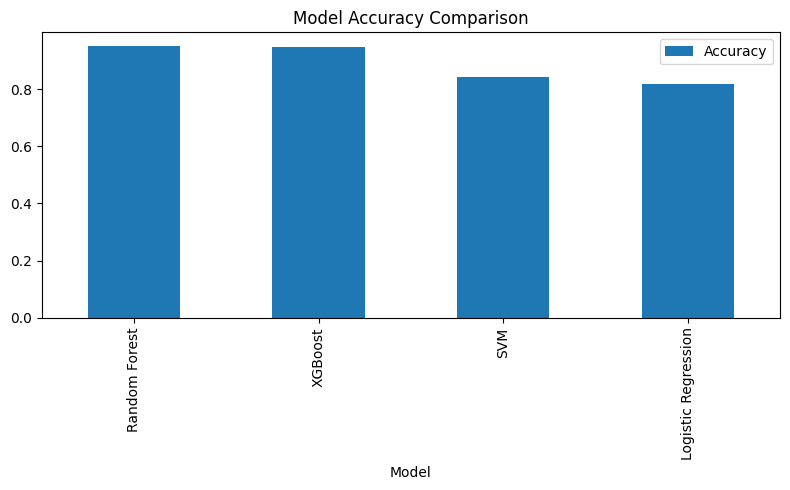

In [40]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Accuracy Comparison")

plt.tight_layout()

plt.savefig(
    "../evaluation/model_accuracy_comparison.png"
)

plt.show()